# Conditional GAN (cGAN)
The example here is for a more complex version that is tuned to generate images. It is known as Conditional Deep Convolutional GAN (cDCGAN)

### Step 1 - Import libraries

In [31]:
# Tensorflow / Keras
from tensorflow import keras # for building Neural Networks
print('Tensorflow/Keras: %s' % keras.__version__) # print version
from keras.models import Model, load_model # for assembling a Neural Network model
from keras.layers import Input, Dense, Embedding, Reshape, Concatenate, Flatten, Dropout # for adding layers
from keras.layers import Conv2D, Conv2DTranspose, MaxPool2D, ReLU, LeakyReLU, BatchNormalization # for adding layers
from tensorflow.keras.utils import plot_model # for plotting model diagram
from tensorflow.keras.optimizers import Adam # for model optimization 

# Data manipulation
import numpy as np # for data manipulation
print('numpy: %s' % np.__version__) # print version

# Visualization
import matplotlib 
import matplotlib.pyplot as plt # for data visualizationa
print('matplotlib: %s' % matplotlib.__version__) # print version
# import graphviz # for showing model diagram
# print('graphviz: %s' % graphviz.__version__) # print version

# Other utilities
import sys
import os
import cv2
import random

# Assign main directory to a variable
main_dir=os.path.dirname(sys.path[0])
print(main_dir)
OUTPUTS_PATH = 'c:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Brain MRI images Classification/Images/'

Tensorflow/Keras: 2.11.0
numpy: 1.22.4
matplotlib: 3.5.3
/


In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)
    google_drive_prefix = "/content/drive/My Drive"
    data_prefix = "{}/brain/".format(google_drive_prefix)
except ModuleNotFoundError: 
    data_prefix = "data/"

Mounted at /content/drive/


In [4]:
path = '/content/drive/My Drive/Datasets/Cropped_Image_Sets/train/'

In [44]:
NOISE_FLOOR = 30
BATCH_SIZE = 32
LATENT_DIM = 100
IMAGE_SIZE = 128
INPUT_SHAPE = 32
G_LEARNING_RATE = 0.002
D_LEARNING_RATE = 0.001
G_DECAY = 0.6
D_DECAY = 0.6
EPOCHS = 20
DISPLAY_SAMPLES = 5
EVALUATION_SUMMARY_RATE = 200

In [54]:
# tf.config.experimental.list_physical_devices('GPU')
# print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# path = 'C:/Users/alime/Dropbox/PC/Documents/Coding/Memoire 2023/Datasets/Brain-Tumor-Dataset-RAW/GAN Training Data/'

def reduce_noise(noisy_img, noise_floor=NOISE_FLOOR):
    clean_img = np.array(noisy_img)
    clean_img[noisy_img < NOISE_FLOOR] = 0
    return clean_img

Images = []
Labels = []
Classes = ['glioma', 'meningioma', 'pituitary']
classes_dict = {'glioma': 0, 'meningioma':1, 'pituitary':2}
# label_val = 0

for Class in classes_dict.keys():
    class_samples = 0
    cpath = os.path.join(path, Class)
    cpath += '/'
    print(cpath)
    for img in os.listdir(cpath):
        class_samples += 1
        image = cv2.imread(os.path.join(cpath, img), cv2.IMREAD_GRAYSCALE)
        
        # Image Enhancements
        # image = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
        image = reduce_noise(image)
        image = cv2.resize(image, (128,128))
        images=(image - 127.5) / 127.5
        
        Images.append(image)
        Labels.append(classes_dict[Class])
    print(f"There are {class_samples} samples in the {Class}")

    # label_val = 1

Images = np.array(Images)
Labels = np.array(Labels)
print("Images: ", Images.shape)
print("Labels: ", Labels.shape)


/content/drive/My Drive/Datasets/Cropped_Image_Sets/train/glioma/
There are 998 samples in the glioma
/content/drive/My Drive/Datasets/Cropped_Image_Sets/train/meningioma/
There are 495 samples in the meningioma
/content/drive/My Drive/Datasets/Cropped_Image_Sets/train/pituitary/
There are 651 samples in the pituitary
Images:  (2144, 128, 128)
Labels:  (2144,)


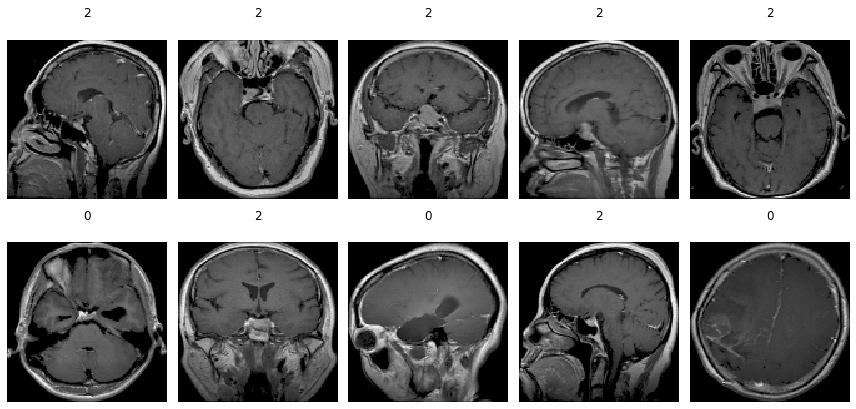

In [55]:
fig, axs = plt.subplots(2, 5, sharey=False, tight_layout=True, figsize=(12,6), facecolor='white')
n=0
for i in range(2):
    for j in range(5):
        random_image = random.randint(0, len(Labels))
        axs[i,j].matshow(Images[random_image], cmap='gray')
        axs[i,j].set(title= Labels[random_image])
        axs[i,j].axis('off')
        n=n+1
plt.show() 

### Step 3 - Setup GAN

In [65]:
def generator(latent_dim, in_shape=(INPUT_SHAPE,INPUT_SHAPE,1), classes_num=len(Classes)):
        
    # Label Inputs
    in_label = Input(shape=(1,), name='Generator-Label-Input-Layer') # Input Layer
    lbls = Embedding(classes_num, 100, name='Generator-Label-Embedding-Layer')(in_label) # Embed label to vector
    
    # Scale up to image dimensions
    n_nodes = in_shape[0] * in_shape[1] # 32x32= 1024 
    lbls = Dense(n_nodes, name='Generator-Label-Dense-Layer')(lbls)
    lbls = Reshape((in_shape[0], in_shape[1], 1), name='Generator-Label-Reshape-Layer')(lbls) # Reshape to additional channel 32x32x1 (Which is the labels channel)

    # Generator Inputs (latent vector)
    in_latent = Input(shape=latent_dim, name='Generator-Latent-Input-Layer')
    
    # Image Foundation 
    n_nodes = INPUT_SHAPE * INPUT_SHAPE * 256 # number of nodes in the initial layer
    g = Dense(n_nodes, name='Generator-Foundation-Layer')(in_latent)
    g = LeakyReLU(alpha=0.2, name='Generator-Foundation-Layer-Activation-1')(g)
    g = Reshape((in_shape[0], in_shape[1], 256), name='Generator-Foundation-Layer-Reshape-1')(g)
    
    # Combine both inputs so it has two channels
    concat = Concatenate(name='Generator-Combine-Layer')([g, lbls])

    # Hidden Layer 1
    g = Conv2DTranspose(filters=256, kernel_size=(4,4), strides=(2,2), padding='same', name='Generator-Hidden-Layer-1')(concat)
    g = BatchNormalization()(g)
    g = LeakyReLU(alpha=0.2, name='Generator-Hidden-Layer-Activation-1')(g)
    
    # Hidden Layer 2
    g = Conv2DTranspose(filters=128, kernel_size=(4,4), strides=(2,2), padding='same', name='Generator-Hidden-Layer-2')(g)
    g = BatchNormalization()(g)
    g = LeakyReLU(alpha=0.2, name='Generator-Hidden-Layer-Activation-2')(g)
    
    # Output Layer (Note, we use 1 filter since we have a greysclae image. Color image would have three
    output_layer = Conv2D(filters=1, kernel_size=(4,4), activation='tanh', padding='same', name='Generator-Output-Layer')(g)
    
    # Define model
    model = Model([in_latent, in_label], output_layer, name='Generator')
    return model

# Instantiate
# Our latent space has 100 dimensions. We can change it to any number
gen_model = generator(LATENT_DIM)

# Show model summary and plot model diagram
gen_model.summary()

# plot_model(gen_model, show_shapes=True, show_layer_names=True, dpi=400, to_file='/content/drive/My Drive/Datasets'+'/generator_structure.png')

Model: "Generator"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Generator-Latent-Input-Layer (  [(None, 100)]       0           []                               
 InputLayer)                                                                                      
                                                                                                  
 Generator-Label-Input-Layer (I  [(None, 1)]         0           []                               
 nputLayer)                                                                                       
                                                                                                  
 Generator-Foundation-Layer (De  (None, 262144)      26476544    ['Generator-Latent-Input-Layer[0]
 nse)                                                            [0]']                    

In [66]:
def discriminator(in_shape=(IMAGE_SIZE,IMAGE_SIZE,1), classes_num=len(Classes)):
    
    # Label Inputs
    in_label = Input(shape=(1,), name='Discriminator-Label-Input-Layer') # Input Layer
    lbls = Embedding(classes_num, 100, name='Discriminator-Label-Embedding-Layer')(in_label) # Embed label to vector
    
    # Scale up to image dimensions
    n_nodes = in_shape[0] * in_shape[1] 
    lbls = Dense(n_nodes, name='Discriminator-Label-Dense-Layer')(lbls)
    lbls = Reshape((in_shape[0], in_shape[1], 1), name='Discriminator-Label-Reshape-Layer')(lbls) # New shape

    # Image Inputs
    in_image = Input(shape=in_shape, name='Discriminator-Image-Input-Layer')
    
    # Combine both inputs so it has two channels
    concat = Concatenate(name='Discriminator-Combine-Layer')([in_image, lbls])

    # Hidden Layer 1
    h = Conv2D(filters=32, kernel_size=(4,4), strides=(2,2), padding='same', name='Discriminator-Hidden-Layer-1')(concat)
    h = BatchNormalization()(h)
    h = LeakyReLU(alpha=0.2, name='Discriminator-Hidden-Layer-Activation-1')(h)
    h = Dropout(0.4, name='Discriminator-Flatten-Layer-Dropout-1')(h) 

    # Hidden Layer 2
    h = Conv2D(filters=64, kernel_size=(4,4), strides=(2,2), padding='same', name='Discriminator-Hidden-Layer-1')(concat)
    h = BatchNormalization()(h)
    h = LeakyReLU(alpha=0.2, name='Discriminator-Hidden-Layer-Activation-1')(h)
    h = Dropout(0.4, name='Discriminator-Flatten-Layer-Dropout-1')(h) 
    
    # Hidden Layer 3
    h = Conv2D(filters=128, kernel_size=(4,4), strides=(2,2), padding='same', name='Discriminator-Hidden-Layer-2')(h)
    h = BatchNormalization()(h)
    h = LeakyReLU(alpha=0.2, name='Discriminator-Hidden-Layer-Activation-2')(h)
    # h = MaxPool2D(pool_size=(3,3), strides=(2,2), padding='valid', name='Discriminator-MaxPool-Layer-2')(h) # Max Pool
    
    # Flatten and Output Layers
    h = Flatten(name='Discriminator-Flatten-Layer')(h) # Flatten the shape
    h = Dropout(0.4, name='Discriminator-Flatten-Layer-Dropout')(h) # Randomly drop some connections for better generalization
   
    output_layer = Dense(1, name='Discriminator-Output-Layer')(h) # Output Layer
    
    # Define model
    model = Model([in_image, in_label], output_layer, name='Discriminator')
    
    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=D_LEARNING_RATE, beta_1=0.5), metrics=['accuracy'])
    return model

# Instantiate
dis_model = discriminator()

# Show model summary and plot model diagram
dis_model.summary()
# plot_model(dis_model, show_shapes=True, show_layer_names=True, dpi=400, to_file=OUTPUTS_PATH+'/discriminator_structure.png')

Model: "Discriminator"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Discriminator-Label-Input-Laye  [(None, 1)]         0           []                               
 r (InputLayer)                                                                                   
                                                                                                  
 Discriminator-Label-Embedding-  (None, 1, 100)      300         ['Discriminator-Label-Input-Layer
 Layer (Embedding)                                               [0][0]']                         
                                                                                                  
 Discriminator-Label-Dense-Laye  (None, 1, 16384)    1654784     ['Discriminator-Label-Embedding-L
 r (Dense)                                                       ayer[0][0]']         

##### Combine Generator and Discriminator models into trainable GAN

In [67]:
def def_gan(generator, discriminator):
    
    # We don't want to train the weights of discriminator at this stage. Hence, make it not trainable
    discriminator.trainable = False
    
    # Get Generator inputs / outputs
    gen_latent, gen_label = generator.input # Latent and label inputs from the generator
    gen_output = generator.output # Generator output image
    
    # Connect image and label from the generator to use as input into the discriminator
    gan_output = discriminator([gen_output, gen_label])
    
    # Define GAN model
    model = Model([gen_latent, gen_label], gan_output, name="cDCGAN")
    
    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=G_LEARNING_RATE, beta_1=0.5))
    return model

# Instantiate
gan_model = def_gan(gen_model, dis_model)

# Show model summary and plot model diagram
gan_model.summary()
# plot_model(gan_model, show_shapes=True, show_layer_names=True, dpi=400, to_file=OUTPUTS_PATH+'/CDCGAN_structure.png')

Model: "cDCGAN"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Generator-Latent-Input-Layer (  [(None, 100)]       0           []                               
 InputLayer)                                                                                      
                                                                                                  
 Generator-Label-Input-Layer (I  [(None, 1)]         0           []                               
 nputLayer)                                                                                       
                                                                                                  
 Generator-Foundation-Layer (De  (None, 262144)      26476544    ['Generator-Latent-Input-Layer[0]
 nse)                                                            [0]']                       

### Step 4 - Setup functions to:
- sample the latent space 
- sample real images
- generate fake images with the generator model

##### Set up a function to sample real images

In [59]:
def real_samples(dataset, categories, n):
    
    # Create a random list of indices
    indx = np.random.randint(0, dataset.shape[0], n)
    
    # Select real data samples (images and category labels) using the list of random indeces from above
    X, cat_labels = dataset[indx], categories[indx]

    # Class labels
    y = np.ones((n, 1))

    return [X, cat_labels], y

##### Generate points in the latent space, which we will use as inputs for the generator

In [60]:
def latent_vector(latent_dim, n, Classes_num=len(Classes)):
    
    # Generate points in the latent space
    latent_input = np.random.randn(latent_dim * n)
    
    # Reshape into a batch of inputs for the network
    latent_input = latent_input.reshape(n, latent_dim)
    
    # Generate category labels 
    cat_labels = np.random.randint(0, Classes_num, n)
    
    return [latent_input, cat_labels]

##### The below function will use the generator to generate n fake examples together with class labels

In [61]:
def fake_samples(generator, latent_dim, n):
    
    # Generate points in latent space
    latent_output, cat_labels = latent_vector(latent_dim, n)
    
    # Predict outputs (i.e., generate fake samples)
    X = generator.predict([latent_output, cat_labels])
    
    # Create class labels
    y = np.zeros((n, 1))
    
    return [X, cat_labels], y

### Step 5 - Setup functions for model performance evaluation and training

##### Show a few fake (generated) images during trraining to get a sense of progress

In [62]:
def show_fakes(generator, latent_dim, n=10):
    
    # Get fake (generated) samples
    x_fake, y_fake = fake_samples(generator, latent_dim, n)
    
    # Rescale from [-1, 1] to [0, 1]
    X_tst = (x_fake[0] + 1) / 2.0
    
    # Display fake (generated) images
    fig, axs = plt.subplots(2, 5, sharey=False, tight_layout=True, figsize=(12,6), facecolor='white')
    k=0
    for i in range(0,2):
        for j in range(0,5):
            axs[i,j].matshow(X_tst[k], cmap='gray')
            axs[i,j].set(title=x_fake[1][k])
            axs[i,j].axis('off')
            k=k+1
    plt.show() 

##### Define a function to train our cDCGAN model (generator and discriminator)

In [68]:
def train(g_model, d_model, gan_model, dataset, categories, latent_dim, n_epochs=EPOCHS, n_batch=BATCH_SIZE, n_eval=EVALUATION_SUMMARY_RATE):
    # Number of batches to use per each epoch
    batch_per_epoch = int(dataset.shape[0] / n_batch)
    print(' batch_per_epoch: ',  batch_per_epoch)
    # Our batch to train the discriminator will consist of half real images and half fake (generated) images
    half_batch = int(n_batch / 2)
    print("Half Batch: ", half_batch)
    # We will manually enumarate epochs 
    for i in range(n_epochs):
        
        # Enumerate batches over the training set
        for j in range(batch_per_epoch):
    
        # Discriminator training
            # Prep real samples
            [x_real, cat_labels_real], y_real = real_samples(dataset, categories, half_batch)
            # [x_real, cat_labels_real], y_real = generate_real_samples(dataset, half_batch)
            # Train discriminator with real samples
            discriminator_loss1, _ = d_model.train_on_batch([x_real, cat_labels_real], y_real)
            
            # Prep fake (generated) samples
            [x_fake, cat_labels_fake], y_fake = fake_samples(g_model, latent_dim, half_batch)
            # Train discriminator with fake samples
            discriminator_loss2, _ = d_model.train_on_batch([x_fake, cat_labels_fake], y_fake)


        # Generator training
            # Get values from the latent space to be used as inputs for the generator
            [latent_input, cat_labels] = latent_vector(latent_dim, n_batch)
            # While we are generating fake samples, 
            # we want GAN generator model to create examples that resemble the real ones,
            # hence we want to pass labels corresponding to real samples, i.e. y=1, not 0.
            y_gan = np.ones((n_batch, 1))

            # Train the generator via a composite GAN model
            generator_loss = gan_model.train_on_batch([latent_input, cat_labels], y_gan)
        
        # Summarize training progress and loss
            if (j) % n_eval == 0:
                print('Epoch: %d, Batch: %d/%d, D_Loss_Total=%.3f, D_Loss_Real=%.3f, D_Loss_Fake=%.3f Gen_Loss=%.3f' % 
                      (i+1, j+1, batch_per_epoch,(discriminator_loss1 + discriminator_loss2) , discriminator_loss1, discriminator_loss2, generator_loss))
                show_fakes(g_model, latent_dim)

### Step 6 - Train the model and display some results

##### Use the above train function to train our cGAN model

 batch_per_epoch:  67
1/1 [==============================] - 0s 169ms/step
Epoch: 1, Batch: 1/67, D_Loss_Real=9.145, D_Loss_Fake=15.249 Gen_Loss=0.000
1/1 [==============================] - 0s 33ms/step


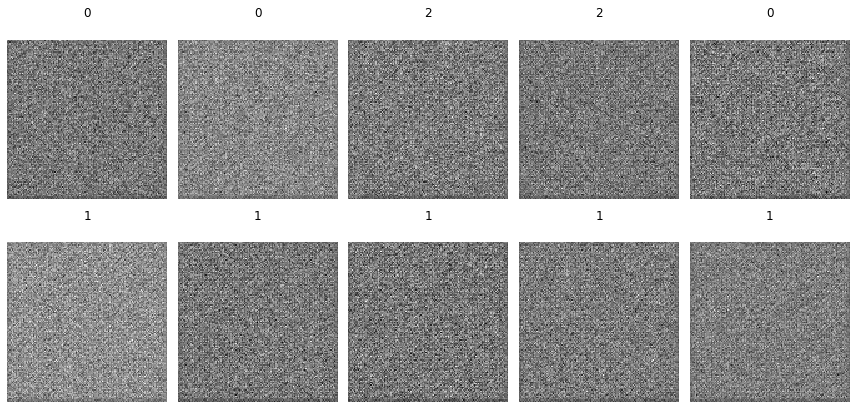

1/1 [==============================] - 0s 25ms/step
Epoch: 2, Batch: 1/67, D_Loss_Real=0.000, D_Loss_Fake=15.249 Gen_Loss=0.000
1/1 [==============================] - 0s 22ms/step


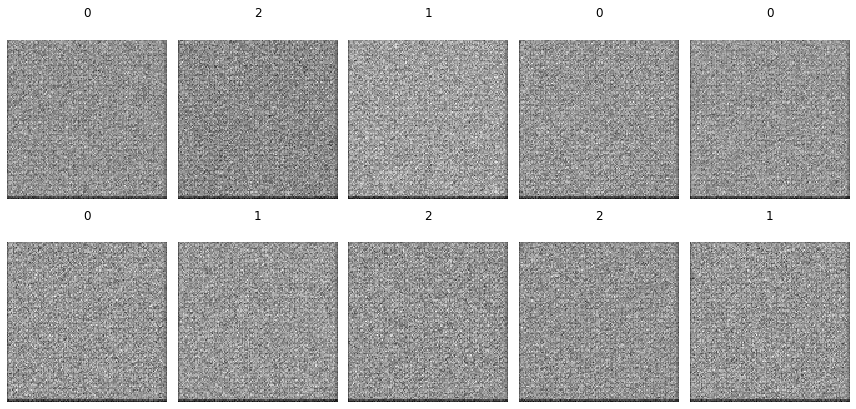

1/1 [==============================] - 0s 40ms/step
Epoch: 3, Batch: 1/67, D_Loss_Real=0.000, D_Loss_Fake=15.249 Gen_Loss=0.000
1/1 [==============================] - 0s 33ms/step


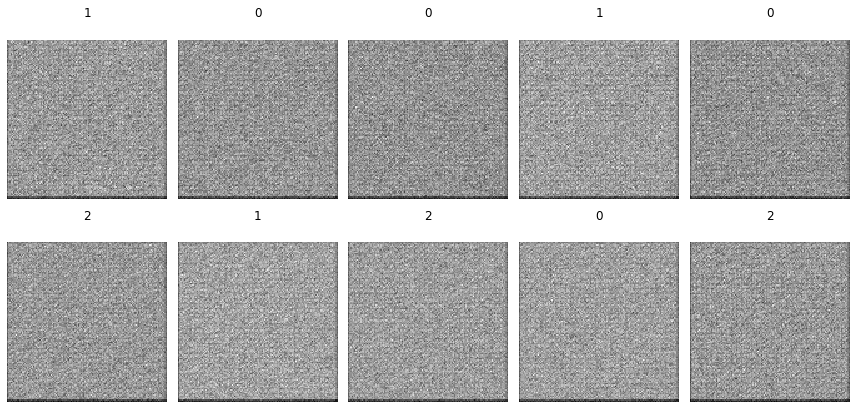

1/1 [==============================] - 0s 21ms/step
Epoch: 4, Batch: 1/67, D_Loss_Real=0.000, D_Loss_Fake=15.249 Gen_Loss=0.000
1/1 [==============================] - 0s 20ms/step


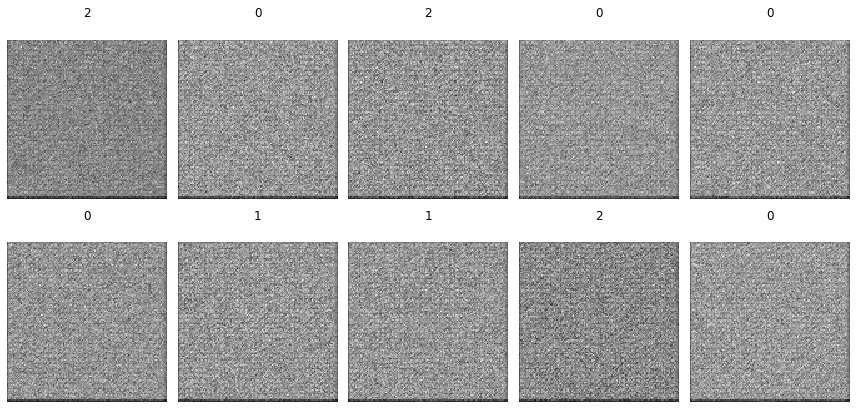

1/1 [==============================] - 0s 21ms/step
Epoch: 5, Batch: 1/67, D_Loss_Real=0.000, D_Loss_Fake=15.249 Gen_Loss=0.000
1/1 [==============================] - 0s 24ms/step


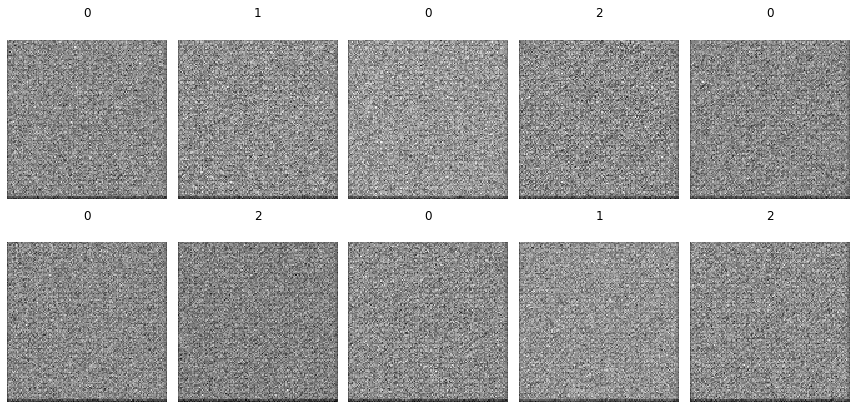

1/1 [==============================] - 0s 23ms/step
Epoch: 6, Batch: 1/67, D_Loss_Real=0.000, D_Loss_Fake=15.249 Gen_Loss=0.000
1/1 [==============================] - 0s 23ms/step


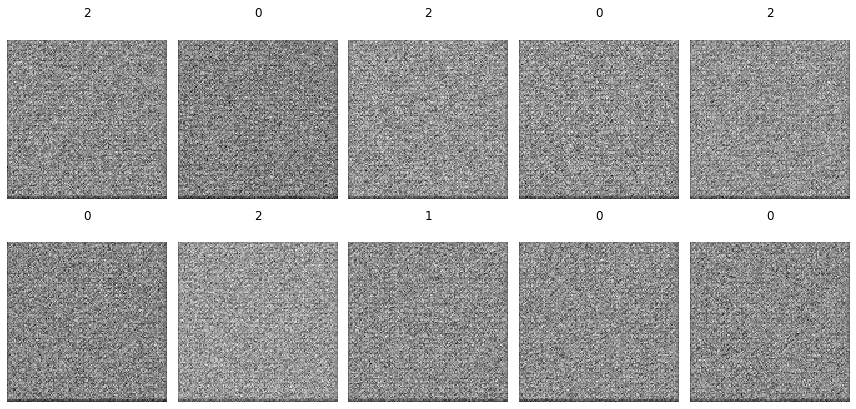

1/1 [==============================] - 0s 22ms/step
Epoch: 7, Batch: 1/67, D_Loss_Real=0.000, D_Loss_Fake=15.249 Gen_Loss=0.000
1/1 [==============================] - 0s 23ms/step


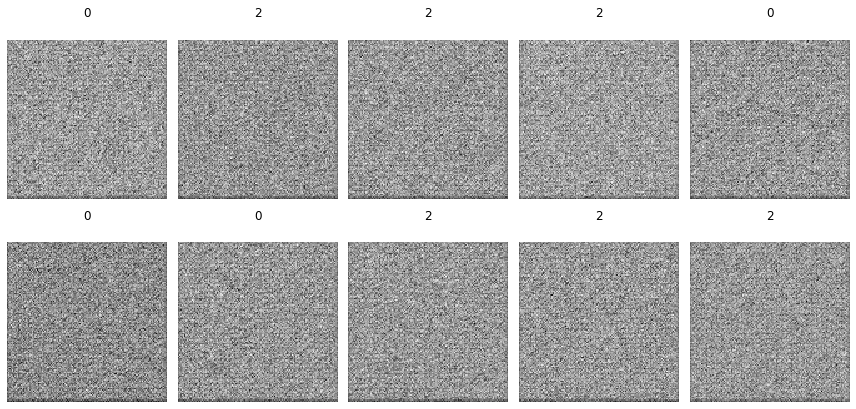

1/1 [==============================] - 0s 23ms/step
Epoch: 8, Batch: 1/67, D_Loss_Real=0.000, D_Loss_Fake=15.249 Gen_Loss=0.000
1/1 [==============================] - 0s 23ms/step


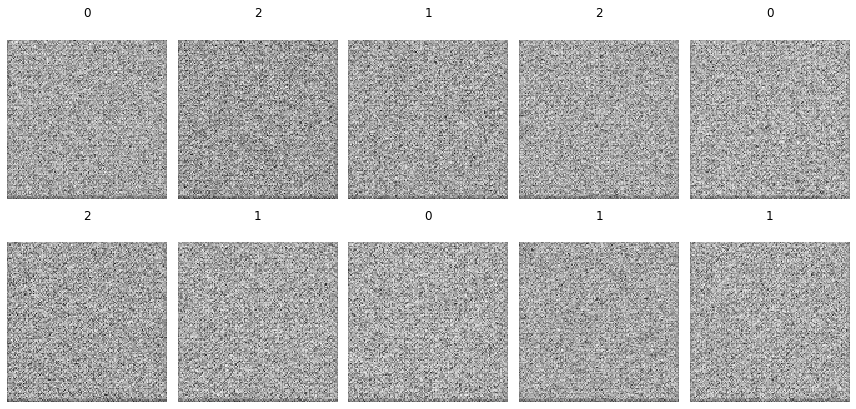

1/1 [==============================] - 0s 24ms/step


KeyboardInterrupt: ignored

In [69]:
# Train cDCGAN model for 10 epochs
train(gen_model, dis_model, gan_model, Images, Labels, LATENT_DIM)

### Step 7 - Save the model and use to it to generate images

##### Save the generator model

In [ ]:
# We need to compile the generator to avoid a warning. This is because we have previously only copiled within the larger cDCGAN model
gen_model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
# Save the Generator on your drive
gen_model.save(main_dir+'/data/cgan_generator.h5')

##### Generate and display images

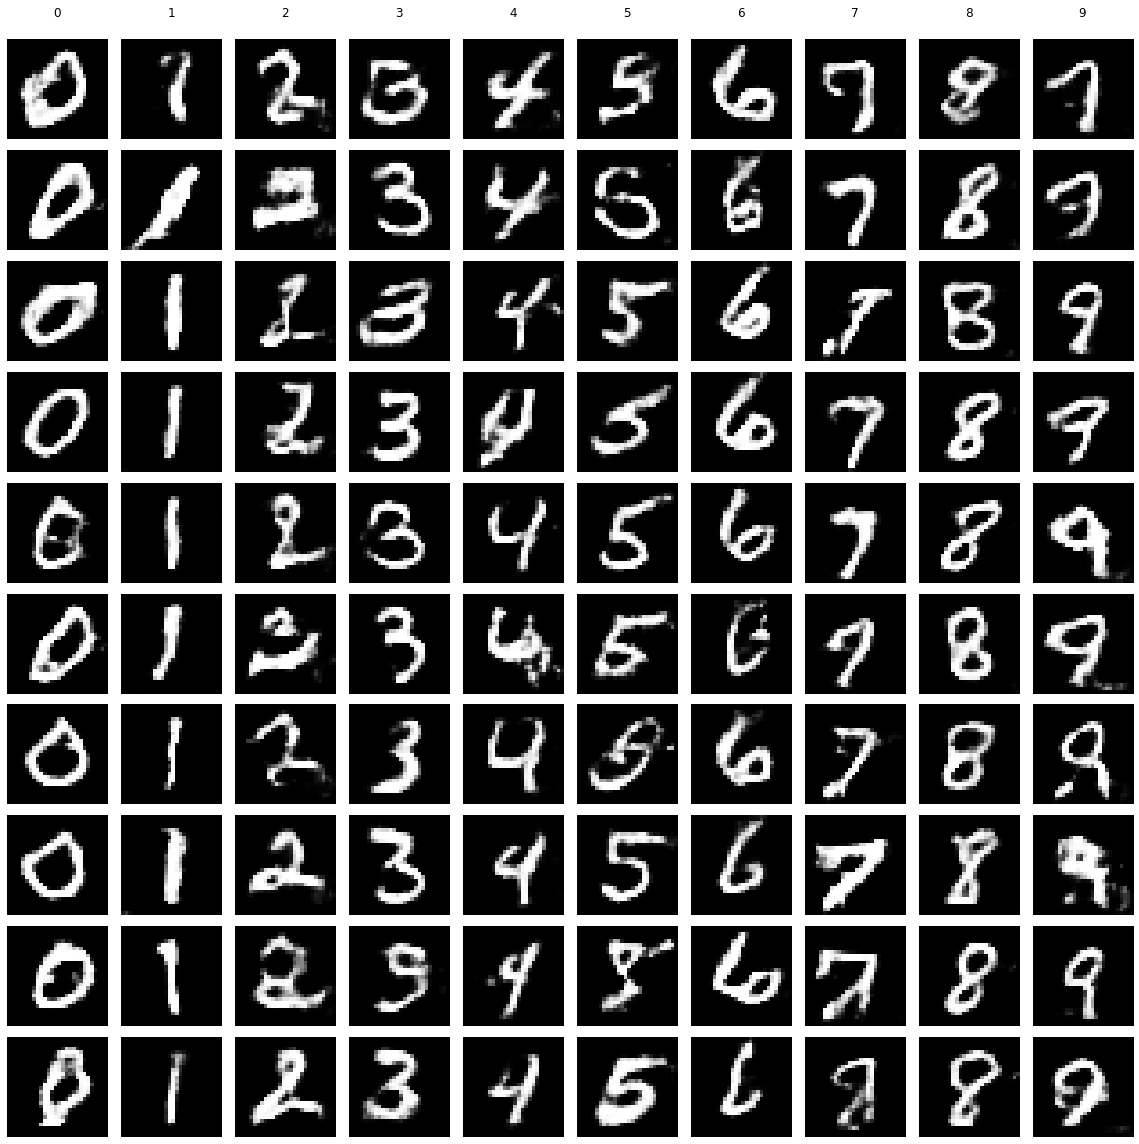

In [ ]:
# Generate latent points
latent_points, _ = latent_vector(100, 100)

# Specify labels that we want (0-9 repeated 10 times)
labels = np.asarray([x for _ in range(10) for x in range(10)])

# Load previously saved generator model
model = load_model(main_dir+'/data/cgan_generator.h5')

# Generate images
gen_imgs  = model.predict([latent_points, labels])

# Scale from [-1, 1] to [0, 1]
gen_imgs = (gen_imgs + 1) / 2.0

# Display images
fig, axs = plt.subplots(10, 10, sharey=False, tight_layout=True, figsize=(16,16), facecolor='white')
k=0
for i in range(0,10):
    for j in range(0,10):
        axs[i,j].matshow(gen_imgs[k], cmap='gray')
        axs[0,j].set(title=labels[k])
        axs[i,j].axis('off')
        k=k+1
plt.show() 

# End of Program